In [3]:
# importing libs
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [4]:
# loading dataset
df = pd.read_csv("/content/student-lifestyle-and-stress-dataset.csv")

df.head()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1


In [5]:
# dataset overview
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset: (25500, 9)

Columns:
Index(['Student_Type', 'Sleep_Hours', 'Study_Hours', 'Social_Media_Hours',
       'Attendance', 'Exam_Pressure', 'Family_Support', 'Month',
       'Stress_Level'],
      dtype='object')

Data Types:
Student_Type           object
Sleep_Hours           float64
Study_Hours           float64
Social_Media_Hours    float64
Attendance            float64
Exam_Pressure         float64
Family_Support        float64
Month                 float64
Stress_Level            int64
dtype: object


In [6]:
# basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  object 
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.8+ MB


In [7]:
# Statistical Summary
df.describe()

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
count,24167.000000,24223.000000,24188.000000,24195.000000,24230.000000,24209.000000,24186.000000,25500.000000
mean,6.458948,4.696477,3.555614,81.270961,5.369748,5.798298,6.500992,0.299882
std,1.504228,2.240148,1.901528,12.052045,2.394003,2.232371,3.455308,0.458215
min,2.008586,-1.433434,0.000040,-5.000000,1.000000,1.000000,1.000000,0.000000
25%,5.438360,3.078230,2.152249,73.738894,4.000000,4.000000,3.000000,0.000000
50%,6.542566,4.538138,3.500709,81.942959,5.000000,6.000000,6.000000,0.000000
75%,7.531571,6.135670,4.864312,90.106859,7.000000,7.000000,10.000000,1.000000
max,9.997527,22.444460,9.962134,120.000000,10.000000,10.000000,12.000000,1.000000


In [8]:
print("Missing values before handling:")
print(df.isnull().sum())

# Dropping rows with any missing values
df.dropna(inplace=True)

print("\nMissing values after dropping rows:")
print(df.isnull().sum())

Missing values before handling:
Student_Type          1252
Sleep_Hours           1333
Study_Hours           1277
Social_Media_Hours    1312
Attendance            1305
Exam_Pressure         1270
Family_Support        1291
Month                 1314
Stress_Level             0
dtype: int64

Missing values after dropping rows:
Student_Type          0
Sleep_Hours           0
Study_Hours           0
Social_Media_Hours    0
Attendance            0
Exam_Pressure         0
Family_Support        0
Month                 0
Stress_Level          0
dtype: int64


In [9]:
# Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
# Correlation Matrix
numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.corr()

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
Sleep_Hours,1.000000,-0.244070,-0.001509,0.004050,0.005521,-0.004430,-0.011309,-0.140540
Study_Hours,-0.244070,1.000000,0.017764,-0.011736,-0.007344,0.019988,0.004993,0.213567
Social_Media_Hours,-0.001509,0.017764,1.000000,-0.000630,-0.006836,0.017743,-0.004702,0.090059
Attendance,0.004050,-0.011736,-0.000630,1.000000,0.008309,0.002770,0.002350,-0.031413
Exam_Pressure,0.005521,-0.007344,-0.006836,0.008309,1.000000,-0.004069,0.013914,0.517973
Family_Support,-0.004430,0.019988,0.017743,0.002770,-0.004069,1.000000,-0.009558,-0.106174
Month,-0.011309,0.004993,-0.004702,0.002350,0.013914,-0.009558,1.000000,-0.048457
Stress_Level,-0.140540,0.213567,0.090059,-0.031413,0.517973,-0.106174,-0.048457,1.000000


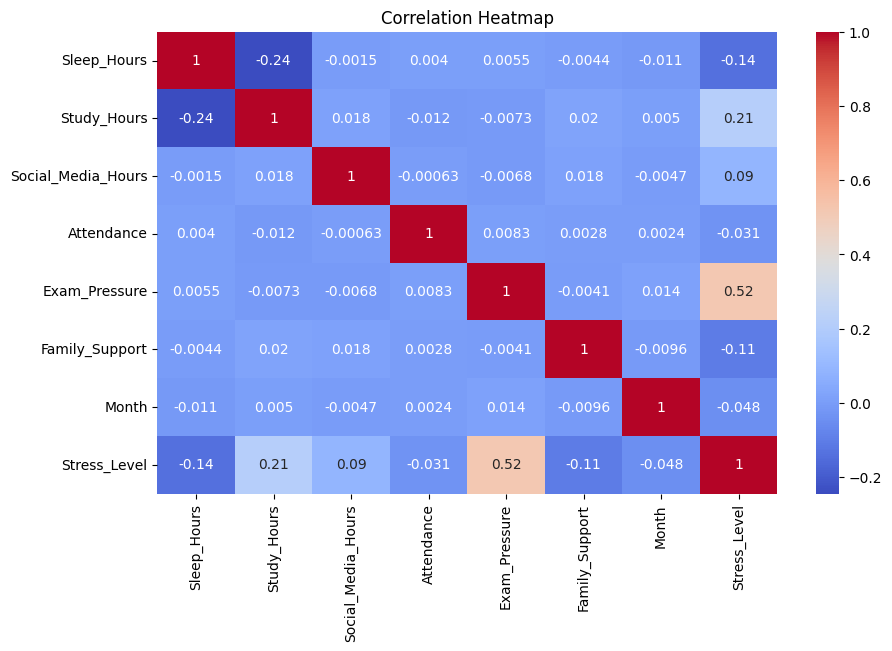

In [11]:
# Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

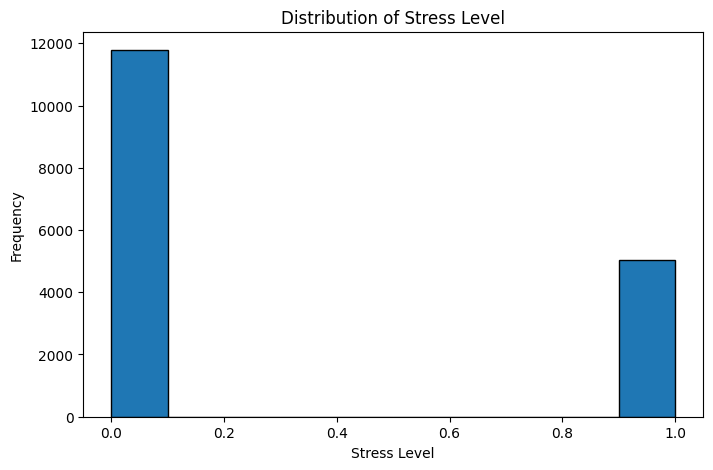

In [12]:
# Stress Level Distribution (Histogram)
plt.figure(figsize=(8,5))

plt.hist(
    df['Stress_Level'],
    bins=10,
    edgecolor='black'
)

plt.title("Distribution of Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Frequency")

plt.show()

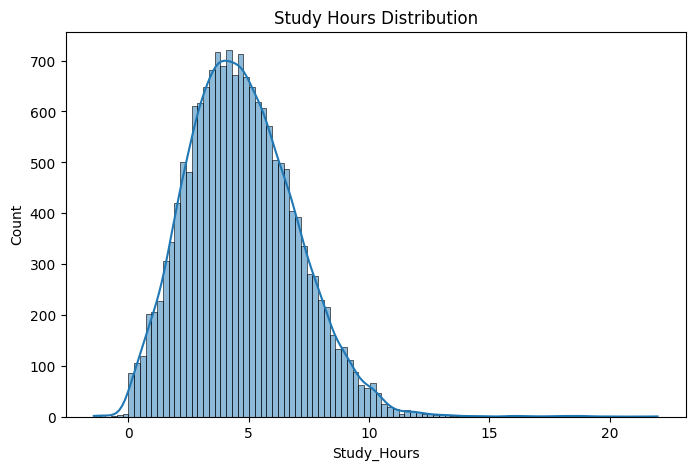

In [13]:
# Study Hours Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['Study_Hours'],
    kde=True
)

plt.title("Study Hours Distribution")
plt.show()

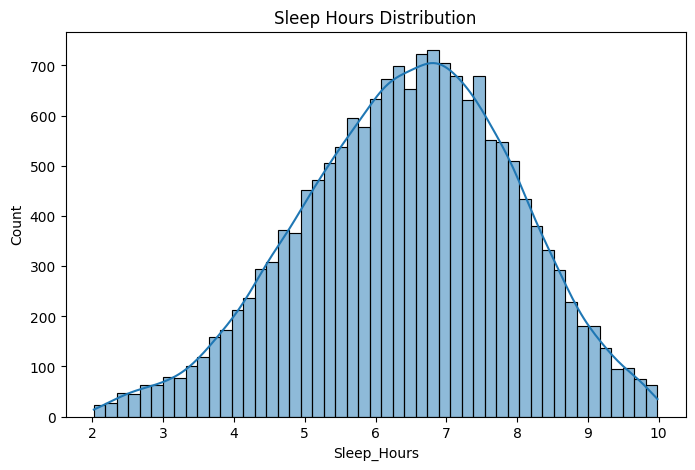

In [14]:
# Sleep Hours Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['Sleep_Hours'],
    kde=True
)

plt.title("Sleep Hours Distribution")
plt.show()

/tmp/ipykernel_9589/407546903.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


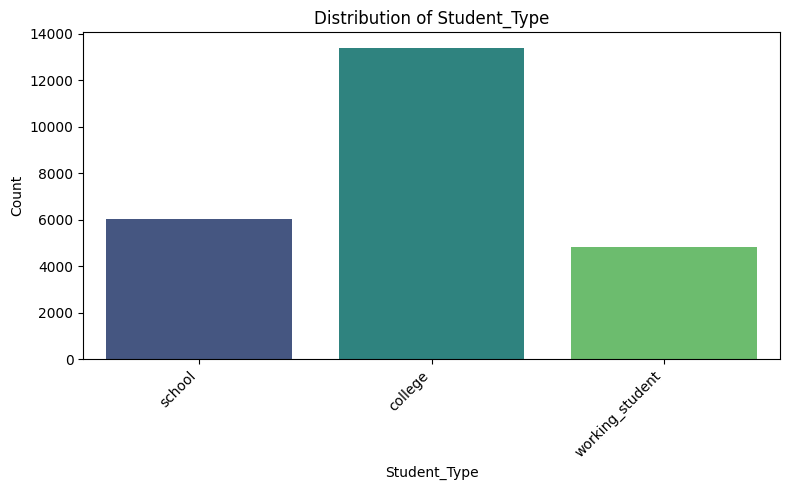

In [15]:
# Bar Chart of Student Categories

# Ensure plotting libraries are imported
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is loaded (in case kernel reset or cells run out of order)
df = pd.read_csv("/content/student-lifestyle-and-stress-dataset.csv")

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Plot distribution for each categorical column
for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


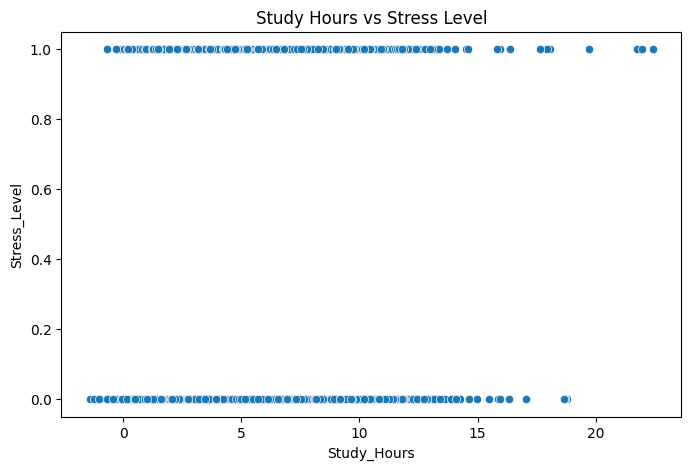

In [16]:
# Stress Level vs Study Hours
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Study_Hours',
    y='Stress_Level',
    data=df
)

plt.title("Study Hours vs Stress Level")

plt.show()

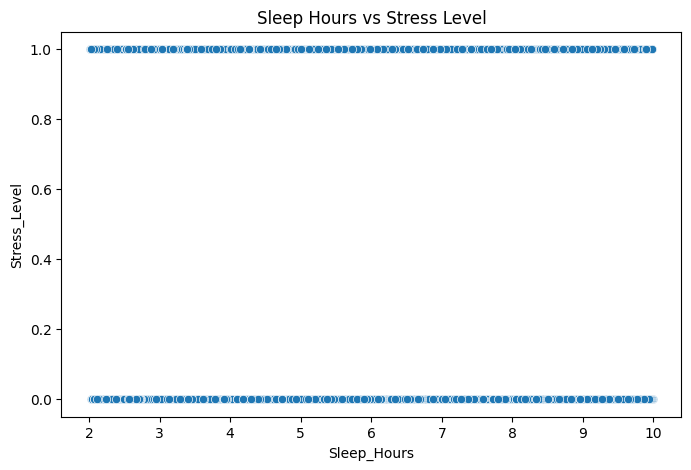

In [17]:
# Stress Level vs Sleep Hours
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Sleep_Hours',
    y='Stress_Level',
    data=df
)

plt.title("Sleep Hours vs Stress Level")

plt.show()

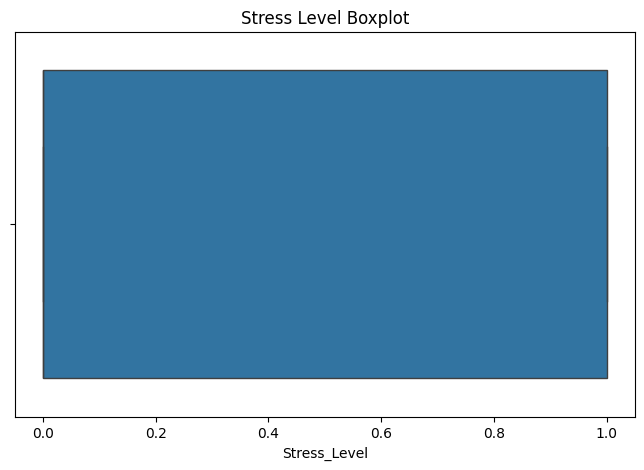

In [18]:
# Boxplot for Outlier Detection
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Stress_Level']
)

plt.title("Stress Level Boxplot")

plt.show()

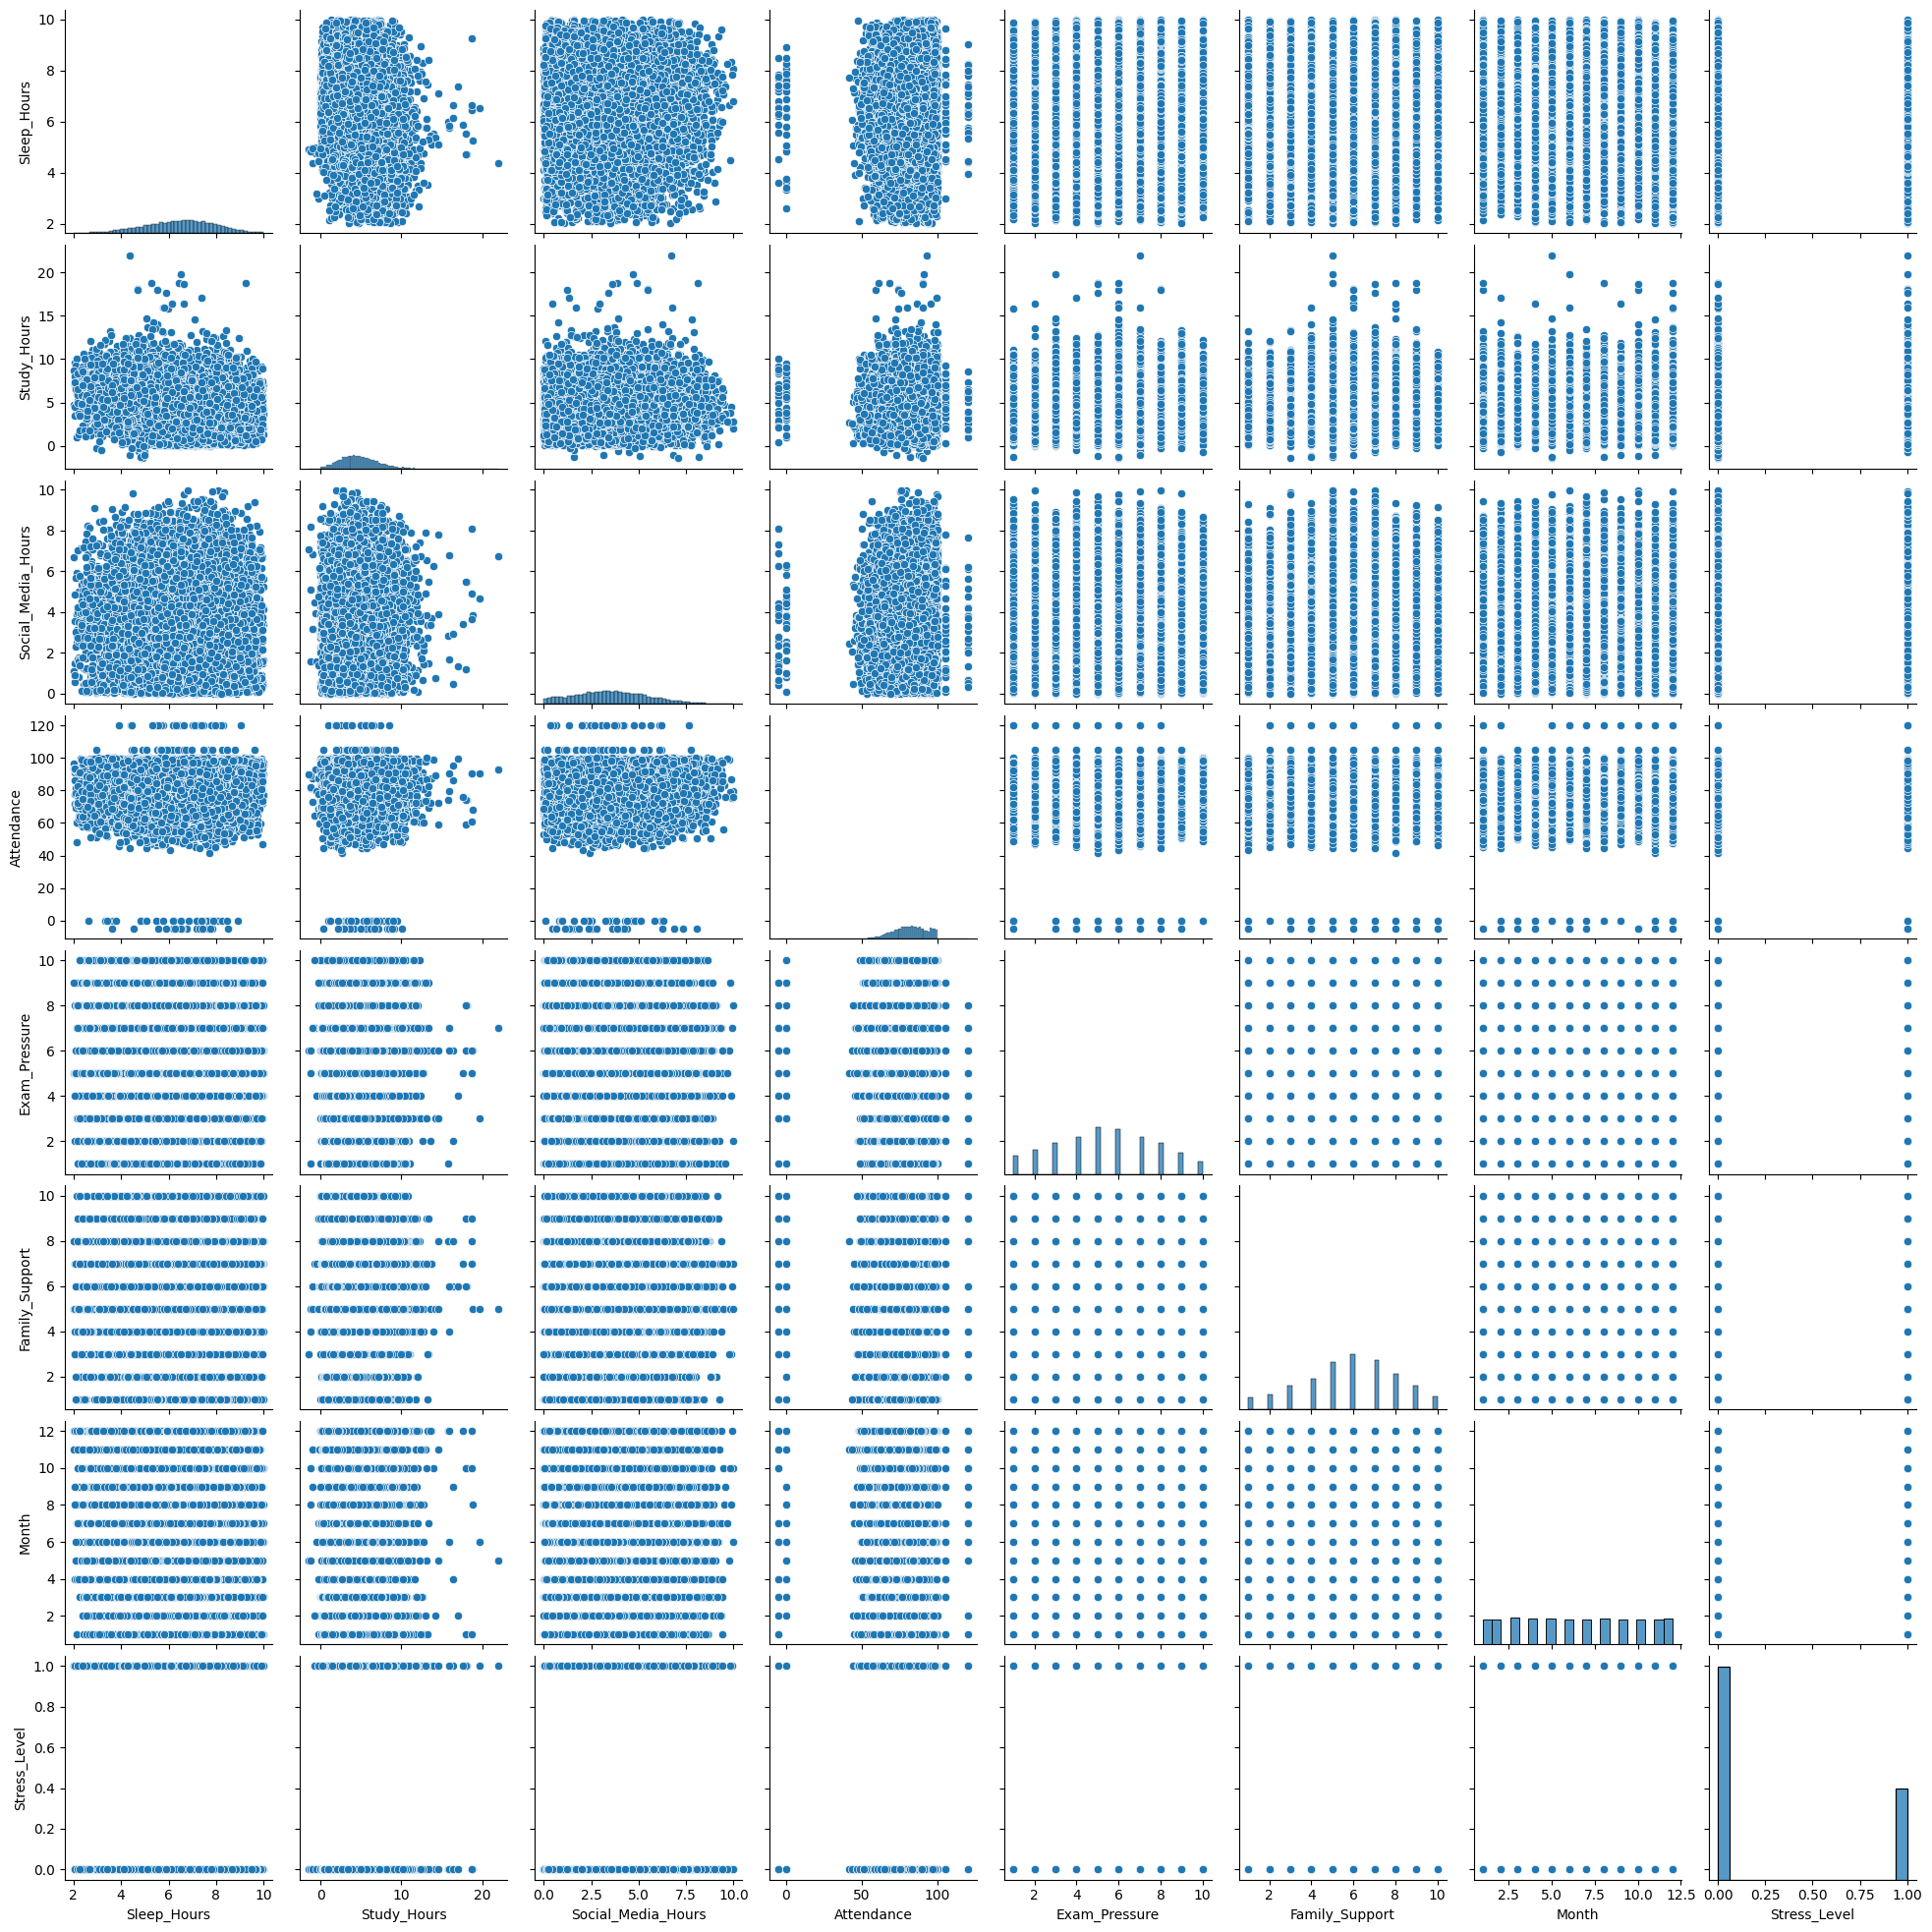

In [19]:
# Pairplot

# Ensure libraries are imported and df is available and cleaned
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reload df and apply cleaning for self-contained execution
df = pd.read_csv("/content/student-lifestyle-and-stress-dataset.csv")
df.dropna(inplace=True)

# Define numeric_df from the cleaned DataFrame
numeric_df = df.select_dtypes(include=['int64','float64'])

sns.pairplot(
    numeric_df
)

plt.show()

In [20]:
# Average Values
numeric_df.mean()

,0
Sleep_Hours,6.451745
Study_Hours,4.714655
Social_Media_Hours,3.548556
Attendance,81.294583
Exam_Pressure,5.359688
Family_Support,5.816051
Month,6.495449
Stress_Level,0.299006


In [21]:
# Median Values
numeric_df.median()

,0
Sleep_Hours,6.527239
Study_Hours,4.554442
Social_Media_Hours,3.486059
Attendance,81.947758
Exam_Pressure,5.000000
Family_Support,6.000000
Month,6.000000
Stress_Level,0.000000


In [22]:
# Standard Deviation
numeric_df.std()

,0
Sleep_Hours,1.504390
Study_Hours,2.246443
Social_Media_Hours,1.896519
Attendance,11.984693
Exam_Pressure,2.399470
Family_Support,2.229343
Month,3.459822
Stress_Level,0.457836


In [23]:
# ave EDA Report Data
df.describe().to_csv("EDA_Summary.csv")